<a href="https://colab.research.google.com/github/Ayushjain270/100-Days-of-Deep-Learning-/blob/main/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

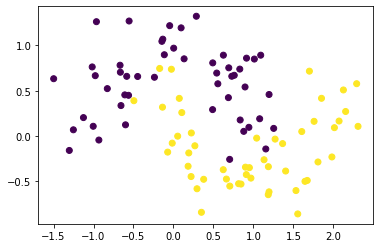

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0], y = X[:,1], c=y)
plt.show()

In [3]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=500, validation_split = 0.2,verbose=1)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.9500 - loss: 0.1248 - val_accuracy: 0.9500 - val_loss: 0.3002
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9250 - loss: 0.2096 - val_accuracy: 0.9000 - val_loss: 0.5747
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9875 - loss: 0.0800 - val_accuracy: 0.9500 - val_loss: 0.1435
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9500 - loss: 0.1299 - val_accuracy: 0.9500 - val_loss: 0.1002
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - loss: 0.1391 - val_accuracy: 0.9500 - val_loss: 0.2643
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9625 - loss: 0.0624 - val_accuracy: 0.9000 - val_loss: 0.4370
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9750 - loss: 0.0650 - val_accuracy: 0.9000 - val_loss: 0.5433
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9750 - loss: 0.0823 - val_accuracy: 0.9000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


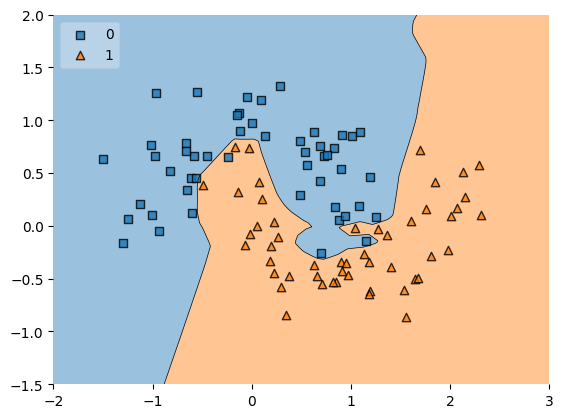

In [6]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

you can check that the the model is very much doing overfitting

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


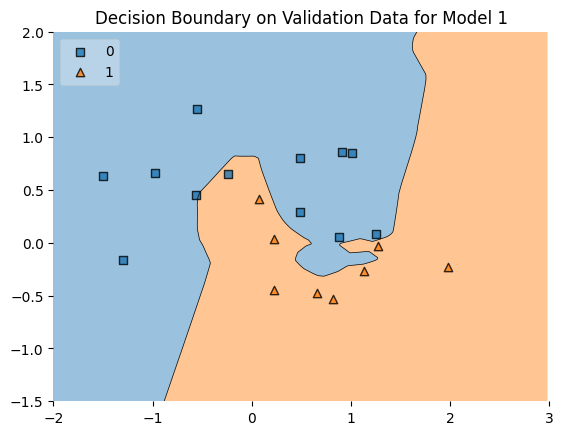

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=None) # Using random_state=None to align with original prompt's implicit behavior

plot_decision_regions(X_val, y_val.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.title('Decision Boundary on Validation Data for Model 1')
plt.show()

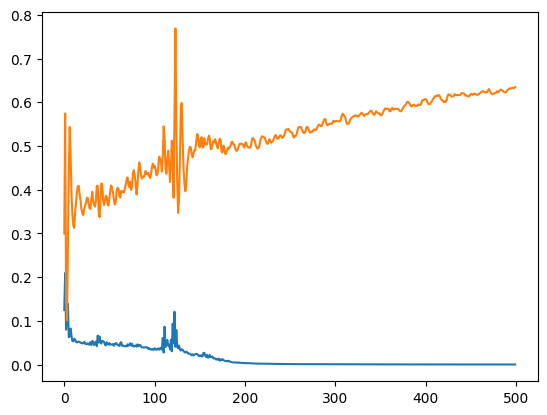

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

the gap between the validation loss and the training loss is very high .. this show that the model is doing overfitting very much

In [13]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.003)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.003)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

in the bracket .. is the value of lambda == 0.003

In [15]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=500, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


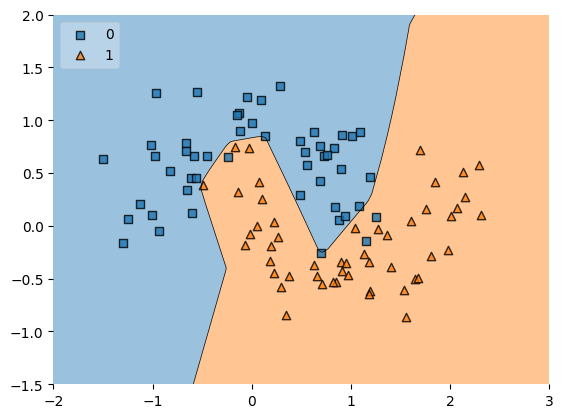

In [16]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

you can see that above decision boundary is bettter than the decision boundary of the model without regularization ...

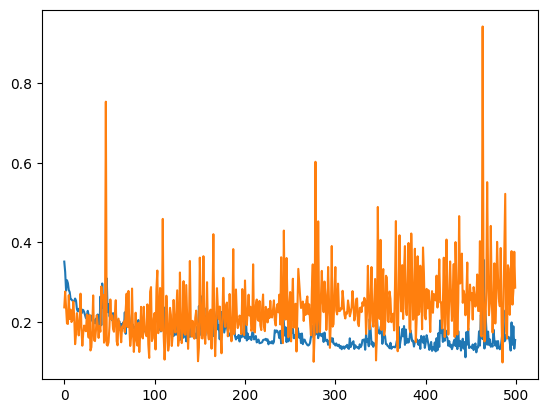

In [17]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

there is no distance between the validation loss and the training loss this shows there is no overfitting .

In [18]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

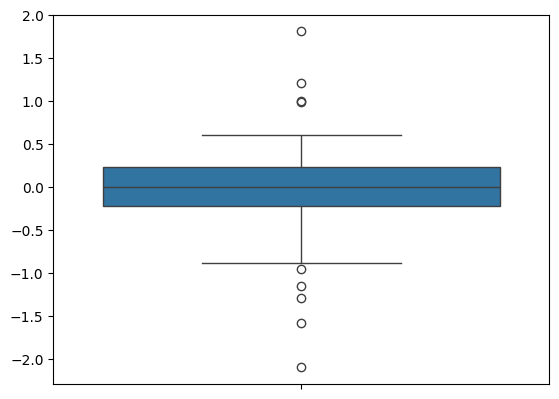

In [19]:
sns.boxplot(model1_weight_layer1)

<Axes: >

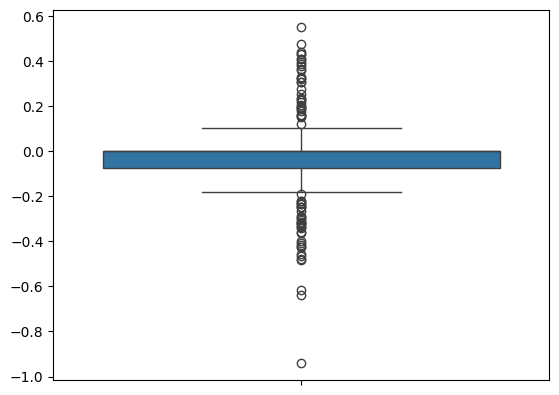

In [20]:
sns.boxplot(model2_weight_layer1)

you can check that after applying the regularization ..the weight decay and comes in the range between the -1 to 0.6 but the model without regularization comes in the range of -2 to 2

In [28]:
model1_weight_layer1.max()

np.float32(1.8056595)

In [27]:
model2_weight_layer1.max()

np.float32(0.554155)

/tmp/ipykernel_510/2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_510/2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

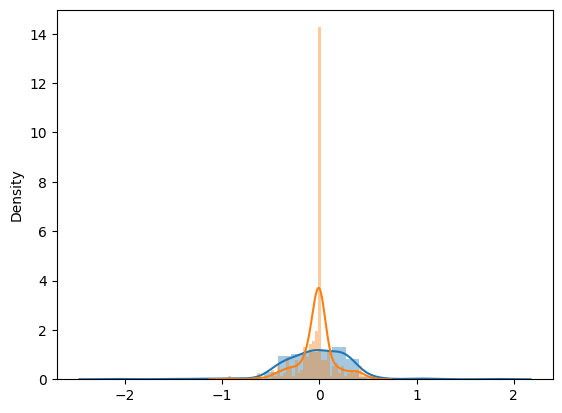

In [23]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

the orange curve is of model with regularization .. that shows that most of the values are concentrated at 0

Now lets apply L1 regularization .. .

In [32]:
model3 = Sequential()

model3.add(Dense(128, input_dim=2, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.l1(0.003)))
model3.add(Dense(128, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.l1(0.003)))
model3.add(Dense(1, activation="sigmoid"))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from sklearn.utils import validation
adam = Adam(learning_rate = 0.01)

model3.compile(loss="binary_crossentropy" , optimizer=adam  , metrics=["accuracy"] )

history3 = model3.fit(X , y , validation_split = 0.2 ,epochs =500  , verbose =1)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.7000 - loss: 4.1618 - val_accuracy: 0.8500 - val_loss: 3.2004
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7750 - loss: 2.9252 - val_accuracy: 0.9000 - val_loss: 2.2051
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8000 - loss: 2.0327 - val_accuracy: 0.9000 - val_loss: 1.4843
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8250 - loss: 1.4509 - val_accuracy: 0.9000 - val_loss: 1.0928
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8500 - loss: 1.1485 - val_accuracy: 0.9000 - val_loss: 1.0189
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8375 - loss: 1.0912 - val_accuracy: 0.9000 - val_loss: 0.9790
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8375 - loss: 1.0647 - val_accuracy: 0.9000 - val_loss: 0.9080
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8375 - loss: 0.9488 - val_accuracy: 0.9000 - val_loss

<Axes: >

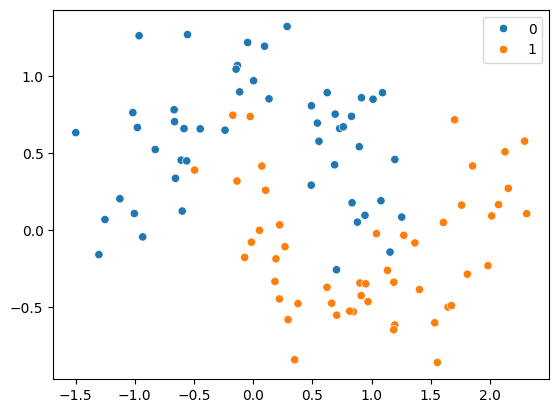

In [44]:
sns.scatterplot(x = X[:,0], y = X[:,1], hue = y)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


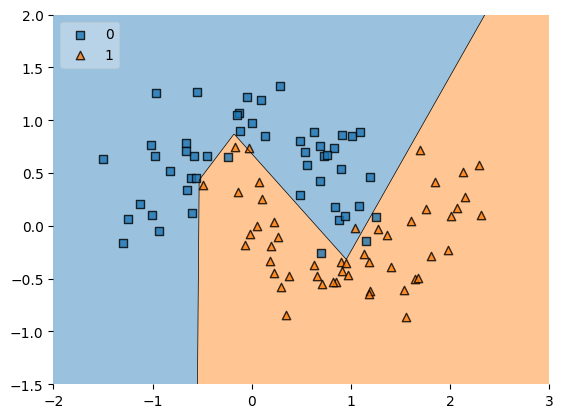

In [45]:
plot_decision_regions(X , y.astype('int') , clf = model3 , legend =2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

In [48]:
model3.get_weights()[0].reshape(256)

array([-1.8740703e-03,  1.9709219e-03, -3.6196309e-04, -1.2682072e-03,
       -5.7956192e-04, -1.4739269e-03,  4.8886763e-04, -1.8183265e-03,
        8.9009316e-04, -1.8534438e-03, -1.5306316e-03,  1.4286523e-03,
       -1.9185474e-03,  2.1783460e-05, -9.0358872e-04, -2.2184441e-04,
       -1.1496137e-04, -1.2225576e-03, -9.2120236e-04, -2.6196684e-04,
        1.3916242e-03,  1.7949846e-05,  1.4716550e-03, -3.2463276e-03,
        5.7805527e-04, -2.5069555e-03, -9.8020944e-05,  4.8207553e-04,
       -7.5569603e-04, -4.0744673e-03, -1.0853212e-04, -9.5761003e-04,
       -8.5481594e-04, -2.6124739e-04, -7.3041464e-04,  3.1343207e-04,
       -1.4756952e-04,  1.2266616e-04,  7.7011762e-04, -1.0780533e-03,
       -2.2831655e+00,  7.4447057e-04, -1.4010924e-03,  2.3127161e-04,
       -7.7875389e-04, -8.1856432e-04,  5.5879224e-05,  1.0285859e+00,
        6.8400812e-04, -2.7806927e-03,  5.5022904e-04,  1.1834346e-03,
       -7.7878777e-04,  5.5110431e-04, -1.0487388e-03, -6.0357584e-04,
      

But Most likely L2 gives better Result than L1 so in Deep Learing always use L2 Regularization
rather than L1 regularization